# 1.0 Environment Setup and Dataset Verification
## 1.1 Library Imports and Dynamic Path Resolution

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tifffile

# 1. Locate all available datasets under Kaggle input directory
input_root = "/kaggle/input"
available_items = os.listdir(input_root)
print("Available items in /kaggle/input:", available_items)

# 2. Automatically select our dataset path
assert len(available_items) > 0, "No datasets found in /kaggle/input"
dataset_folder_name = available_items[0]
data_dir = os.path.join(input_root, dataset_folder_name)

print(f"\nTarget Dataset Path: {data_dir}")
print("Directory Contents:")

for item in sorted(os.listdir(data_dir)):
    item_path = os.path.join(data_dir, item)
    if os.path.isdir(item_path):
        print(f"  [Folder] {item} -> {len(os.listdir(item_path))} files")
    else:
        print(f"  [File]   {item}")

Available items in /kaggle/input: ['datasets']

Target Dataset Path: /kaggle/input/datasets
Directory Contents:
  [Folder] mohamedelbasyouni55 -> 1 files


## 1.2 Automatic Path Discovery and Metadata Loading

In [2]:
# 1. Recursively search for the exact directory containing metadata.csv
data_root = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "metadata.csv" in files or ("images" in dirs and "labels" in dirs):
        data_root = root
        break

assert data_root is not None, "Could not locate dataset directory containing metadata.csv"

print(f"Exact Dataset Root Found: {data_root}")
print(f"Sub-directories / Files: {os.listdir(data_root)}")

# 2. Load metadata.csv into Pandas DataFrame
metadata_file = os.path.join(data_root, "metadata.csv")
df_meta = pd.read_csv(metadata_file)

print(f"\nMetadata DataFrame loaded successfully! Total records: {len(df_meta)}")
df_meta.head(10)

Exact Dataset Root Found: /kaggle/input/datasets/mohamedelbasyouni55/water-segmentation-multispectral
Sub-directories / Files: ['satalite data', 'metadata.csv']

Metadata DataFrame loaded successfully! Total records: 456


,sample_id,image_path,mask_path,is_matched,has_water,water_pixels,water_percentage
0,0,images/0.tif,labels/0.png,1,1,1917,11.70
1,1,images/1.tif,labels/1.png,1,1,182,1.11
2,2,images/2.tif,labels/2.png,1,1,11768,71.83
3,3,images/3.tif,labels/3.png,1,1,871,5.32
4,4,images/4.tif,labels/4.png,1,1,325,1.98
5,5,images/5.tif,labels/5.png,1,0,0,0.00
6,6,images/6.tif,labels/6.png,1,1,279,1.70
7,7,images/7.tif,labels/7.png,1,1,38,0.23
8,8,images/8.tif,labels/8.png,1,1,2490,15.20
9,9,images/9.tif,labels/9.png,1,1,6805,41.53


# 2.0 Dataset Analysis and Label Distribution
## 2.1 Water Presence and Coverage Statistics

Verified Images Directory: /kaggle/input/datasets/mohamedelbasyouni55/water-segmentation-multispectral/satalite data/data/images (306 files)
Verified Labels Directory: /kaggle/input/datasets/mohamedelbasyouni55/water-segmentation-multispectral/satalite data/data/labels (456 files)

Total Matched Samples:    306
Samples Containing Water: 261 (85.29%)
Samples With Land Only:   45 (14.71%)


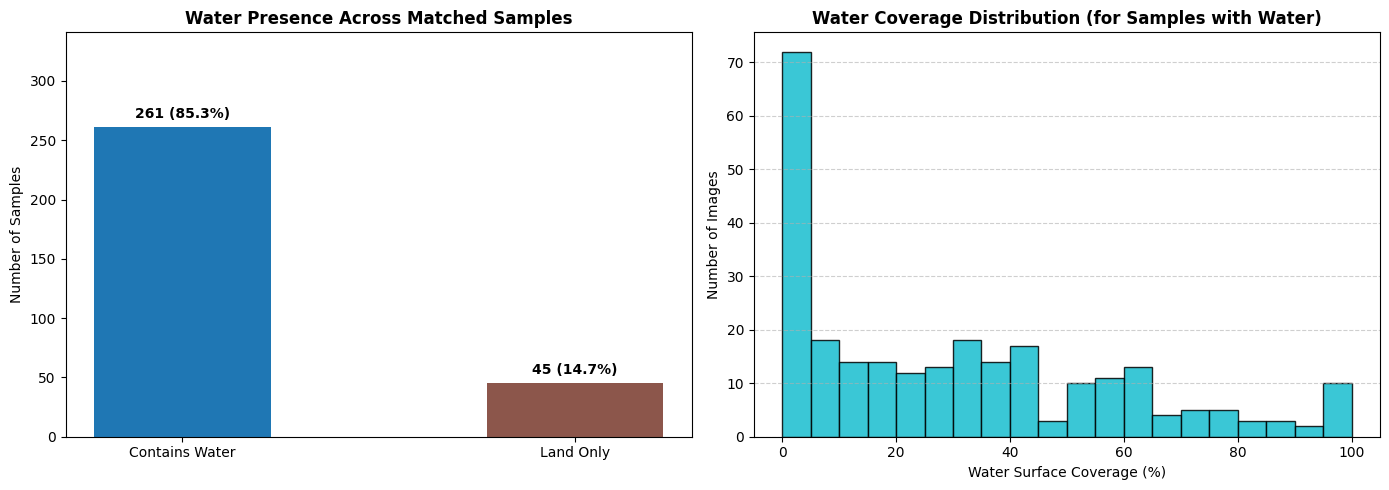

In [3]:
# 1. Dynamically locate 'images' and 'labels' directories anywhere inside dataset root
images_dir = None
labels_dir = None

for root, dirs, files in os.walk(data_root):
    if "images" in dirs:
        images_dir = os.path.join(root, "images")
    if "labels" in dirs:
        labels_dir = os.path.join(root, "labels")

assert images_dir is not None, "Could not find 'images' folder"
assert labels_dir is not None, "Could not find 'labels' folder"

print(f"Verified Images Directory: {images_dir} ({len(os.listdir(images_dir))} files)")
print(f"Verified Labels Directory: {labels_dir} ({len(os.listdir(labels_dir))} files)")

# 2. Filter for matched training samples (images with corresponding masks)
matched_df = df_meta[df_meta["is_matched"] == 1].copy()

n_total = len(matched_df)
n_water = int(matched_df["has_water"].sum())
n_dry = n_total - n_water

print("\n" + "=" * 50)
print(f"Total Matched Samples:    {n_total}")
print(f"Samples Containing Water: {n_water} ({n_water / n_total * 100:.2f}%)")
print(f"Samples With Land Only:   {n_dry} ({n_dry / n_total * 100:.2f}%)")
print("=" * 50)

# 3. Visual Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Water vs Land-only samples count
bars = axes[0].bar(
    ["Contains Water", "Land Only"], 
    [n_water, n_dry], 
    color=["#1f77b4", "#8c564b"], 
    width=0.45
)
axes[0].set_title("Water Presence Across Matched Samples", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Number of Samples")
axes[0].set_ylim(0, n_total + 35)

for bar in bars:
    y = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, y + 5, f"{int(y)} ({y / n_total * 100:.1f}%)", ha="center", va="bottom", fontweight="bold")

# Plot B: Water coverage percentage distribution
water_pcts = matched_df[matched_df["has_water"] == 1]["water_percentage"]
axes[1].hist(water_pcts, bins=20, color="#17becf", edgecolor="black", alpha=0.85)
axes[1].set_title("Water Coverage Distribution (for Samples with Water)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Water Surface Coverage (%)")
axes[1].set_ylabel("Number of Images")
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# 3.0 Multispectral Bands Inspection and Visualization
## 3.1 Individual Visualization of All 12 Spectral Bands

Sample ID:           0
Image Shape on Disk: (128, 128, 12) (Height, Width, Channels)
Image Data Type:     int16
Mask Shape:          (128, 128)
Water Pixels:        1917 (11.70% coverage)


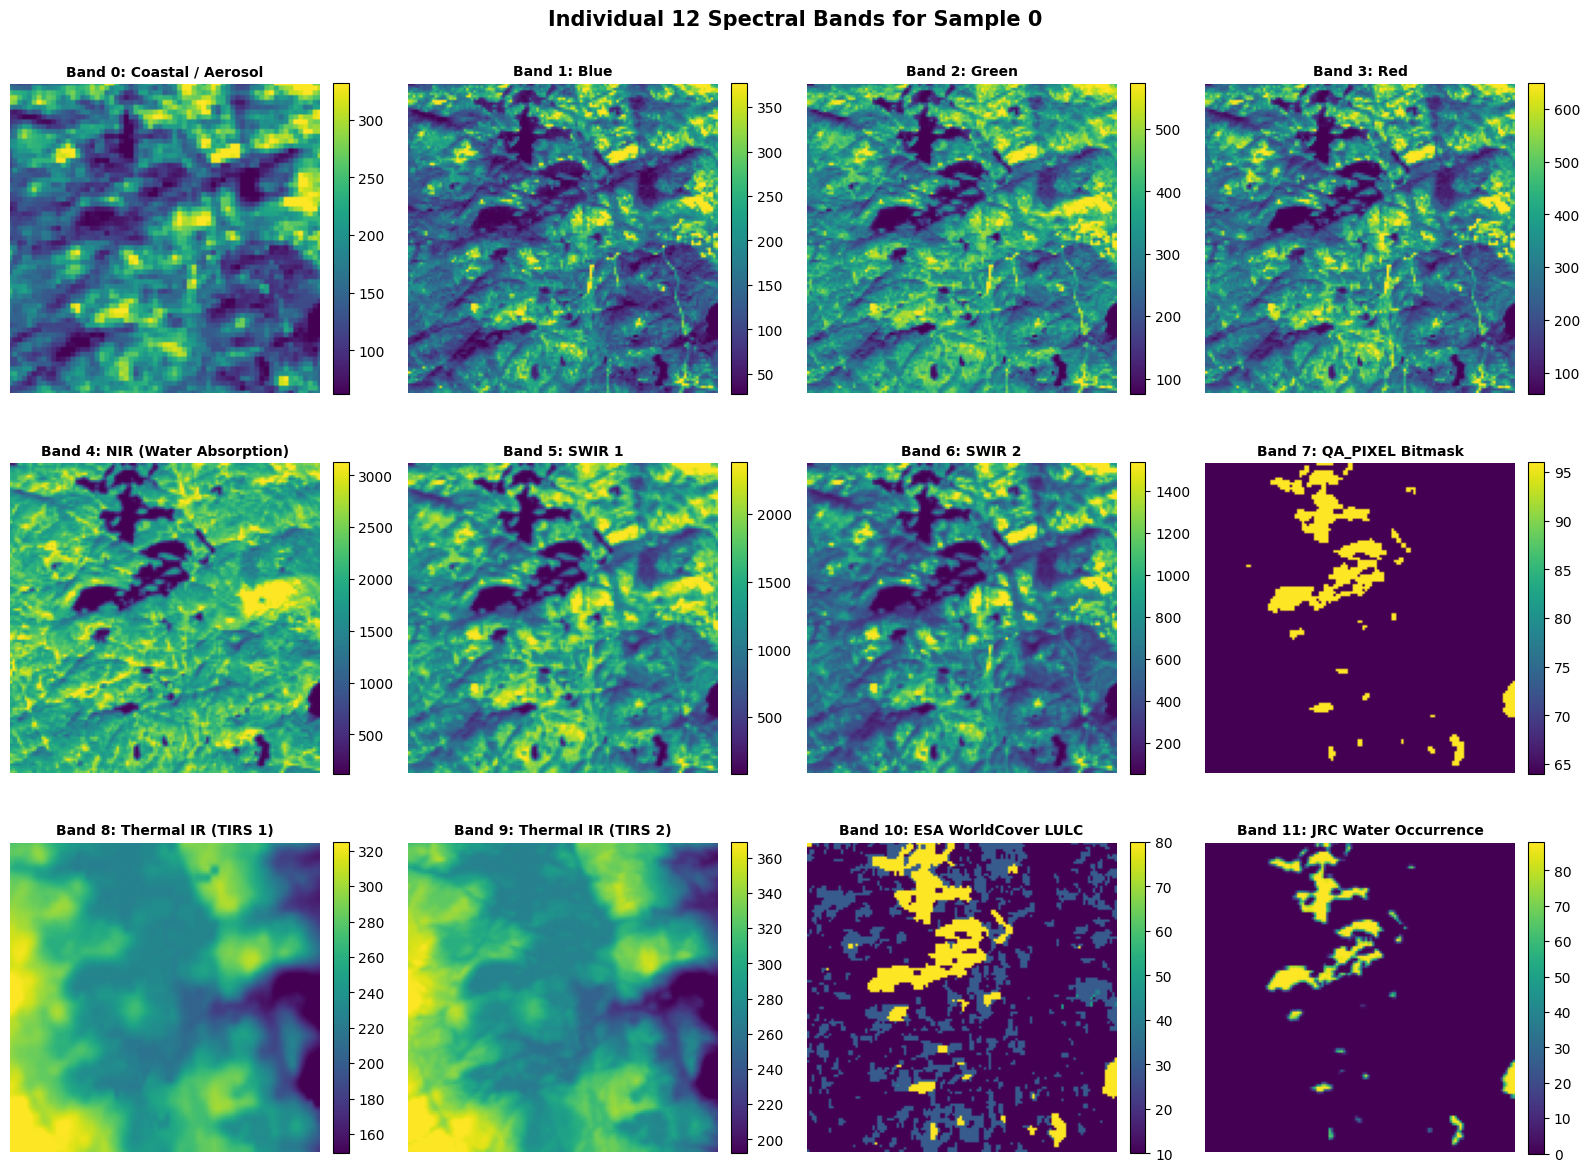

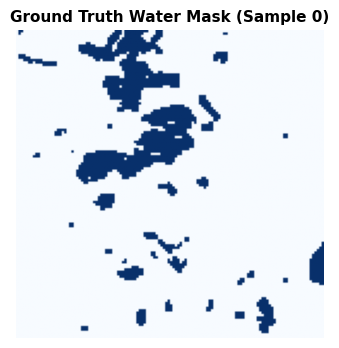

In [4]:
# 1. Select the first matched sample directly via position index
sample_row = matched_df.iloc[0]
sample_idx = str(sample_row["sample_id"])

img_file = os.path.join(images_dir, f"{sample_idx}.tif")
lbl_file = os.path.join(labels_dir, f"{sample_idx}.png")

# 2. Read 12-channel multispectral image and binary mask
img_12b = tifffile.imread(img_file)
mask_img = np.array(Image.open(lbl_file))

print(f"Sample ID:           {sample_idx}")
print(f"Image Shape on Disk: {img_12b.shape} (Height, Width, Channels)")
print(f"Image Data Type:     {img_12b.dtype}")
print(f"Mask Shape:          {mask_img.shape}")
print(f"Water Pixels:        {sample_row['water_pixels']} ({sample_row['water_percentage']:.2f}% coverage)")

# 3. Band Names and Physical Meanings
band_labels = [
    "Band 0: Coastal / Aerosol",
    "Band 1: Blue",
    "Band 2: Green",
    "Band 3: Red",
    "Band 4: NIR (Water Absorption)",
    "Band 5: SWIR 1",
    "Band 6: SWIR 2",
    "Band 7: QA_PIXEL Bitmask",
    "Band 8: Thermal IR (TIRS 1)",
    "Band 9: Thermal IR (TIRS 2)",
    "Band 10: ESA WorldCover LULC",
    "Band 11: JRC Water Occurrence"
]

# 4. Plot 12 bands in a 3x4 grid + ground truth mask
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for b in range(12):
    row = b // 4
    col = b % 4
    ax = axes[row, col]
    
    band_data = img_12b[:, :, b].astype(np.float32)
    
    # Handle NoData and normalize display
    valid_data = band_data[band_data > -9000]
    vmin = np.percentile(valid_data, 2) if len(valid_data) > 0 else 0
    vmax = np.percentile(valid_data, 98) if len(valid_data) > 0 else 1
    
    im = ax.imshow(band_data, cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(band_labels[b], fontsize=10, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"Individual 12 Spectral Bands for Sample {sample_idx}", fontsize=15, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

# 5. Display Ground Truth Mask
plt.figure(figsize=(4, 4))
plt.imshow(mask_img, cmap="Blues")
plt.title(f"Ground Truth Water Mask (Sample {sample_idx})", fontsize=11, fontweight="bold")
plt.axis("off")
plt.show()

## 3.2 True Color (RGB) vs False Color and Water Index (NDWI)

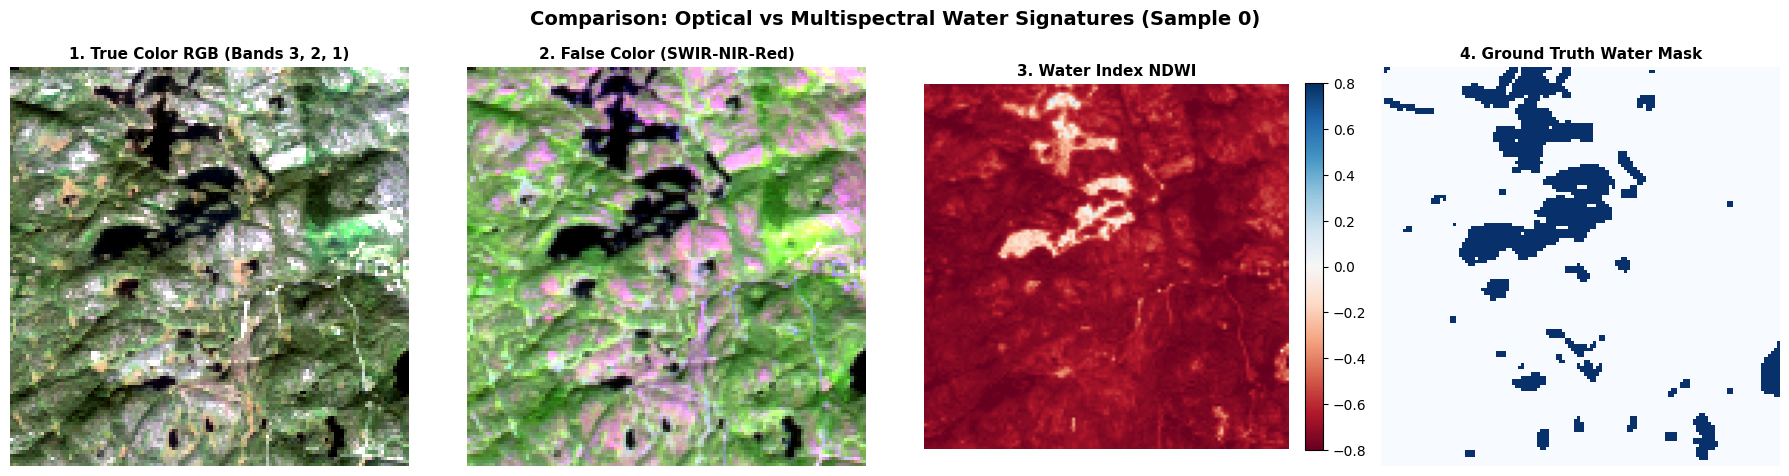

In [5]:
def normalize_rgb(img_channels):
    """Normalize a 3-channel array to 0-1 using robust 2-98 percentiles for visualization."""
    rgb = np.zeros_like(img_channels, dtype=np.float32)
    for c in range(3):
        ch = img_channels[:, :, c].astype(np.float32)
        valid = ch[ch > -9000]
        vmin = np.percentile(valid, 2) if len(valid) > 0 else 0
        vmax = np.percentile(valid, 98) if len(valid) > 0 else 1
        rgb[:, :, c] = np.clip((ch - vmin) / (vmax - vmin + 1e-6), 0, 1)
    return rgb

# 1. True Color RGB: Red (Band 3), Green (Band 2), Blue (Band 1)
true_color_raw = np.stack([img_12b[:, :, 3], img_12b[:, :, 2], img_12b[:, :, 1]], axis=-1)
true_color = normalize_rgb(true_color_raw)

# 2. False Color Infrared: SWIR1 (Band 5), NIR (Band 4), Red (Band 3)
false_color_raw = np.stack([img_12b[:, :, 5], img_12b[:, :, 4], img_12b[:, :, 3]], axis=-1)
false_color = normalize_rgb(false_color_raw)

# 3. Normalized Difference Water Index (NDWI): (Green - NIR) / (Green + NIR)
green = img_12b[:, :, 2].astype(np.float32)
nir = img_12b[:, :, 4].astype(np.float32)
ndwi = (green - nir) / (green + nir + 1e-6)

# 4. Display 4-panel comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(true_color)
axes[0].set_title("1. True Color RGB (Bands 3, 2, 1)", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(false_color)
axes[1].set_title("2. False Color (SWIR-NIR-Red)", fontsize=11, fontweight="bold")
axes[1].axis("off")

im_ndwi = axes[2].imshow(ndwi, cmap="RdBu", vmin=-0.8, vmax=0.8)
axes[2].set_title("3. Water Index NDWI", fontsize=11, fontweight="bold")
axes[2].axis("off")
plt.colorbar(im_ndwi, ax=axes[2], fraction=0.046, pad=0.04)

axes[3].imshow(mask_img, cmap="Blues")
axes[3].set_title("4. Ground Truth Water Mask", fontsize=11, fontweight="bold")
axes[3].axis("off")

plt.suptitle(f"Comparison: Optical vs Multispectral Water Signatures (Sample {sample_idx})", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 4.0 Preprocessing Pipeline and Per-Band Normalization
## 4.1 Global Band Statistics and Tensor Shape Verification

In [6]:
# 1. Compute per-band distribution statistics across matched samples
sample_ids = matched_df["sample_id"].astype(str).tolist()
band_accumulators = {b: [] for b in range(12)}

print("Computing robust per-band statistics across dataset samples...")

for sid in sample_ids[:100]:  # 100 samples provide highly stable statistics in seconds
    fpath = os.path.join(images_dir, f"{sid}.tif")
    arr = tifffile.imread(fpath).astype(np.float32)
    
    for b in range(12):
        ch = arr[:, :, b]
        valid = ch[ch > -9000]
        if len(valid) > 0:
            if b <= 6:
                valid = np.clip(valid, 0, None)
            band_accumulators[b].extend(valid[::16])

# 2. Build summary table of band statistics
stats_rows = []
for b in range(12):
    data = np.array(band_accumulators[b])
    stats_rows.append({
        "Band": f"Band {b}",
        "Name": band_labels[b].split(": ")[1],
        "Min": round(float(np.min(data)), 2),
        "Max": round(float(np.max(data)), 2),
        "Mean": round(float(np.mean(data)), 2),
        "Std": round(float(np.std(data)), 2),
    })

df_stats = pd.DataFrame(stats_rows)
print("\nGlobal Band Statistics:")
display(df_stats)

# 3. Define the Per-Band Normalization function
def preprocess_multispectral_sample(img_raw):
    """
    Transforms raw (128, 128, 12) int16 image into normalized (12, 128, 128) float32 tensor:
    - Cleans -9999 NoData values
    - Clips negative surface reflectance for physical bands (0-6)
    - Normalizes each band to [0, 1] range using global bounds
    - Transposes shape from (H, W, C) to PyTorch standard (C, H, W)
    """
    img = img_raw.astype(np.float32).copy()
    c_first = np.zeros((12, img.shape[0], img.shape[1]), dtype=np.float32)
    
    for b in range(12):
        ch = img[:, :, b]
        ch[ch < -9000] = 0.0
        if b <= 6:
            ch = np.clip(ch, 0.0, None)
        
        b_min = df_stats.loc[b, "Min"]
        b_max = df_stats.loc[b, "Max"]
        norm_ch = (ch - b_min) / (b_max - b_min + 1e-6)
        c_first[b] = np.clip(norm_ch, 0.0, 1.0)
        
    return c_first

# 4. Verify on Sample 0
norm_tensor = preprocess_multispectral_sample(img_12b)

print("\n" + "=" * 55)
print("PREPROCESSING SHAPE AND INTEGRITY VERIFICATION:")
print(f"Original Input Shape on Disk:  {img_12b.shape} (Height, Width, Channels)")
print(f"Preprocessed Output Shape:     {norm_tensor.shape} (Channels, Height, Width)")
print(f"Matches Required (12, 128, 128): {norm_tensor.shape == (12, 128, 128)}")
print(f"Output Value Range:            Min={norm_tensor.min():.4f}, Max={norm_tensor.max():.4f}")
print(f"Missing / Infinite Values:     {np.isnan(norm_tensor).sum()} NaNs, {np.isinf(norm_tensor).sum()} Infs")
print("=" * 55)

Computing robust per-band statistics across dataset samples...

Global Band Statistics:


,Band,Name,Min,Max,Mean,Std
0,Band 0,Coastal / Aerosol,0.0,4649.0,379.37,242.51
1,Band 1,Blue,0.0,5132.0,466.22,292.71
2,Band 2,Green,0.0,5661.0,773.84,376.59
3,Band 3,Red,0.0,6217.0,902.22,534.61
4,Band 4,NIR (Water Absorption),0.0,6535.0,2092.90,1002.26
5,Band 5,SWIR 1,0.0,6758.0,1933.62,1139.99
6,Band 6,SWIR 2,0.0,5547.0,1298.10,909.48
7,Band 7,QA_PIXEL Bitmask,64.0,255.0,98.11,45.91
8,Band 8,Thermal IR (TIRS 1),11.0,2784.0,331.96,506.63
9,Band 9,Thermal IR (TIRS 2),9.0,2762.0,331.38,502.73



PREPROCESSING SHAPE AND INTEGRITY VERIFICATION:
Original Input Shape on Disk:  (128, 128, 12) (Height, Width, Channels)
Preprocessed Output Shape:     (12, 128, 128) (Channels, Height, Width)
Matches Required (12, 128, 128): True
Output Value Range:            Min=0.0000, Max=0.9700
Missing / Infinite Values:     0 NaNs, 0 Infs


# 5.0 Key Findings and Modeling Strategy

### Summary of Exploratory Data Analysis:
1. **Dataset Dimensions & Integrity**: 
   - 306 matched pairs of multi-band `.tif` images and `.png` binary masks.
   - All raw images have native dimensions of `(128, 128, 12)` in `int16`.
   - The preprocessing pipeline successfully standardizes inputs to `(12, 128, 128)` normalized float tensors with zero NaNs.

2. **Spectral Superiority over RGB**:
   - While water bodies in True Color RGB (Bands 3, 2, 1) are visually ambiguous and blend with surrounding terrain shadows, Near-Infrared (Band 4) and Shortwave-Infrared (Bands 5 & 6) exhibit near-total water absorption.
   - The Normalized Difference Water Index (NDWI) computed from Band 2 and Band 4 provides exceptional contrast between land (-0.8 to -0.2) and water bodies (> +0.2).

3. **Class Distribution**:
   - 85.29% of matched samples contain water bodies, while 14.71% are completely dry land samples.
   - This natural distribution prevents false-positive bias while ensuring sufficient water edge patterns.

4. **Next Step**:
   - Proceed to notebook `02-water-segmentation-train` for building the custom 12-channel U-Net from scratch and conducting GPU training.